# Stage 3: Synthetic Generation (Budget Sweep)

Having identified that Transfer Learning performance is deeply affected by the distance between domains (the Conditional Shift of the anomalies), we now test whether synthetic data generation can bridge that gap. 

Instead of an uncontrolled interpolation sweep, we follow a strict evaluation protocol to answer two questions:
1. How does the synthetic generator perform when starved of target data (evaluating at budgets of 1%, 5%, 10%, and 25%)?
2. Does the generator actually amplify the information of the real target data (comparing 1x generation vs 5x and 10x generation)?


In [76]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.linalg
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
import ot
import warnings
import random

def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

## 1. Data Preparation

We extract the anomalous datapoints from the Spring (Source) and Summer (Target) domains. We specifically focus on this single temporal shift (out of the 24 possible pairs) for two reasons: First, training deep generative models from scratch for every budget across all pairs is computationally prohibitive. Second, as seen in Stage 2, the Spring $\rightarrow$ Summer shift produced a massive Transfer Penalty, providing a high ceiling to demonstrate the efficacy of synthetic generation.

To rigorously evaluate the data-efficiency of our generative models, we split the Target domain exactly as we did in Stage 2: 50% into a pool (from which we will draw our tiny budgets) and 50% into a strict test set. We focus exclusively on the anomalies, as that is where the domain shift causes the F1 score to collapse.


In [77]:
print("Loading data...")
DATA_FILE = '../data/metropt3/MetroPT3(AirCompressor).csv'
df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)
df['Anomaly'] = 0

FAILURES = {
    1: {'type': 'Air Leak', 'start': '2020-04-18 00:00:00', 'end': '2020-04-18 23:59:00'},
    2: {'type': 'Air Leak', 'start': '2020-05-29 23:30:00', 'end': '2020-05-30 06:00:00'},
    3: {'type': 'Air Leak', 'start': '2020-06-05 10:00:00', 'end': '2020-06-07 14:30:00'},
    4: {'type': 'Air Leak', 'start': '2020-07-15 14:30:00', 'end': '2020-07-15 19:00:00'}
}
for failure_id, info in FAILURES.items():
    start = pd.to_datetime(info['start'])
    end = pd.to_datetime(info['end'])
    df.loc[start:end, 'Anomaly'] = 1

ANALOG_SENSORS = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']

def assign_season(month):
    if month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Other'

df['Month'] = df.index.month
df['Season'] = df['Month'].apply(assign_season)

source_full = df[df['Season'] == 'Spring']
target_full = df[df['Season'] == 'Summer']

n_source = min(50000, len(source_full))
n_target = min(50000, len(target_full))
src_sample = source_full.sample(n_source, random_state=42)
tgt_sample = target_full.sample(n_target, random_state=42)

# Source Split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    src_sample[ANALOG_SENSORS], src_sample['Anomaly'], test_size=0.2, random_state=42)

# Target Split (50% pool, 50% test - exactly matching Stage 2)
tgt_pool_full, tgt_test_full = train_test_split(tgt_sample, test_size=0.5, random_state=42)

X_t_test, y_t_test = tgt_test_full[ANALOG_SENSORS], tgt_test_full['Anomaly']

# Extract Anomalies for Generator Training and Distance
src_anom = X_train_s[y_train_s == 1].values
tgt_pool_anom = tgt_pool_full[tgt_pool_full['Anomaly'] == 1][ANALOG_SENSORS].values
tgt_test_anom = tgt_test_full[tgt_test_full['Anomaly'] == 1][ANALOG_SENSORS].values

print(f"Source Anomalies: {len(src_anom)}")
print(f"Target Pool Anomalies: {len(tgt_pool_anom)}")
print(f"Target Test Anomalies: {len(tgt_test_anom)}")

scaler = StandardScaler()
scaler.fit(np.vstack([src_anom, tgt_pool_anom]))
scaler.scale_ = np.maximum(scaler.scale_, 1e-3)

src_scaled = scaler.transform(src_anom)
tgt_test_scaled = scaler.transform(tgt_test_anom)

Loading data...
Source Anomalies: 627
Target Pool Anomalies: 709
Target Test Anomalies: 701


## 2. Distance Metrics

We use the same geometric distance metrics (SWD, MMD, FD) defined and analyzed in Stage 2 to measure the discrepancy between the augmented training sets and the Target Test set. We will use these to track if closing the mathematical distance correlates with a reduction in the Transfer Penalty.


In [78]:
def mmd_rbf(X, Y, gamma=0.1):
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

def frechet_distance(X, Y):
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False) + 1e-3 * np.eye(X.shape[1])
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False) + 1e-3 * np.eye(Y.shape[1])
    diff = mu1 - mu2
    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    if isinstance(covmean, tuple): covmean = covmean[0]
    if np.iscomplexobj(covmean): covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)

def compute_distances(X, Y):
    if len(X) < 2 or len(Y) < 2:
        return {'SWD': np.nan, 'MMD': np.nan, 'FD': np.nan}
    return {
        'SWD': ot.sliced_wasserstein_distance(X, Y, n_projections=50),
        'MMD': mmd_rbf(X, Y, gamma=0.1),
        'FD': frechet_distance(X, Y)
    }

## 3. Generator Architectures

We define two generative models:
1.  **Conditional VAE (CVAE):** Disentangles the failure physics from the environmental conditions by feeding the domain label `c` into both the encoder and decoder.
2.  **Conditional GAN (CGAN):** A min-max adversarial network similarly conditioned on the domain label.

We test both to determine which architecture is more robust when starved of target data.


In [79]:
class CVAE(nn.Module):
    def __init__(self, input_dim=7, latent_dim=16, cond_dim=1, hidden_dim=64):
        super().__init__()
        self.enc_fc1 = nn.Linear(input_dim + cond_dim, hidden_dim)
        self.enc_fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)
        
        self.dec_fc1 = nn.Linear(latent_dim + cond_dim, hidden_dim // 2)
        self.dec_fc2 = nn.Linear(hidden_dim // 2, hidden_dim)
        self.dec_out = nn.Linear(hidden_dim, input_dim)
        self.relu = nn.ReLU()
    
    def encode(self, x, c):
        h = self.relu(self.enc_fc1(torch.cat([x, c], dim=1)))
        h = self.relu(self.enc_fc2(h))
        return self.fc_mu(h), self.fc_logvar(h)
    
    def decode(self, z, c):
        h = self.relu(self.dec_fc1(torch.cat([z, c], dim=1)))
        h = self.relu(self.dec_fc2(h))
        return self.dec_out(h)
    
    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        return self.decode(z, c), mu, logvar

class CGANGenerator(nn.Module):
    def __init__(self, noise_dim=16, cond_dim=1, hidden_dim=64, output_dim=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + cond_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, z, c): return self.net(torch.cat([z, c], dim=1))

class CGANDiscriminator(nn.Module):
    def __init__(self, input_dim=7, cond_dim=1, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + cond_dim, hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1), nn.Sigmoid()
        )
    def forward(self, x, c): return self.net(torch.cat([x, c], dim=1))

## 4. Training Utilities

Standard training loops for the CVAE and CGAN.


In [80]:
def train_cvae(X_train, c_train, epochs=300):
    model = CVAE()
    opt = optim.Adam(model.parameters(), lr=1e-3)
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(c_train, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    
    model.train()
    for _ in range(epochs):
        for x, c in loader:
            opt.zero_grad()
            recon, mu, logvar = model(x, c)
            loss = nn.functional.mse_loss(recon, x, reduction='sum') - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss.backward()
            opt.step()
    return model

def train_cgan(X_train, c_train, epochs=300):
    gen = CGANGenerator()
    disc = CGANDiscriminator()
    opt_g = optim.Adam(gen.parameters(), lr=2e-4)
    opt_d = optim.Adam(disc.parameters(), lr=2e-4)
    bce = nn.BCELoss()
    
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(c_train, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    
    for _ in range(epochs):
        for x_real, c_real in loader:
            bs = x_real.size(0)
            valid = torch.ones(bs, 1)
            fake = torch.zeros(bs, 1)
            
            # Train Disc
            opt_d.zero_grad()
            z = torch.randn(bs, 16)
            x_fake = gen(z, c_real).detach()
            d_loss = bce(disc(x_real, c_real), valid) + bce(disc(x_fake, c_real), fake)
            d_loss.backward()
            opt_d.step()
            
            # Train Gen
            opt_g.zero_grad()
            z = torch.randn(bs, 16)
            g_loss = bce(disc(gen(z, c_real), c_real), valid)
            g_loss.backward()
            opt_g.step()
    return gen

## 5. Evaluation Utility

For each scenario in the sweep, we combine the Source data with the Augmented anomalies (either Real or Synthetic). We compute the geometric distance to the Target Test set, and then train a Random Forest classifier to compute the Transfer Penalty.


In [81]:
def evaluate_scenario(scenario_name, budget_pct, N, added_anom_scaled, run_idx=0):
    """Evaluates the augmented training set on the Target Test set."""
    # Combine Source + Added Anomalies for distance
    augmented_anom_scaled = np.vstack([src_scaled, added_anom_scaled]) if len(added_anom_scaled) > 0 else src_scaled
    dists = compute_distances(augmented_anom_scaled, tgt_test_scaled)
    
    # Inverse transform for classifier training
    if len(added_anom_scaled) > 0:
        added_anom_raw = scaler.inverse_transform(added_anom_scaled)
        added_df = pd.DataFrame(added_anom_raw, columns=ANALOG_SENSORS)
        added_y = pd.Series([1] * len(added_df), name='Anomaly')
        X_train_aug = pd.concat([X_train_s, added_df], ignore_index=True)
        y_train_aug = pd.concat([y_train_s, added_y], ignore_index=True)
    else:
        X_train_aug, y_train_aug = X_train_s.copy(), y_train_s.copy()
        
    rf = RandomForestClassifier(n_estimators=100, random_state=42 + run_idx, n_jobs=-1)
    rf.fit(X_train_aug, y_train_aug)
    
    rf_baseline = f1_score(y_test_s, rf.predict(X_test_s), zero_division=0)
    rf_transfer = f1_score(y_t_test, rf.predict(X_t_test), zero_division=0)
    
    return {
        'Scenario': scenario_name,
        'Budget %': budget_pct,
        'N (Real Samples)': N,
        'Run': run_idx,
        'Transfer F1': rf_transfer,
        'Transfer Penalty': rf_baseline - rf_transfer,
        **dists
    }

## 6. The Budget Sweep

This is the core loop, enhanced with a rigorous **Multi-Seed Evaluation**. To prove the mathematical stability of our models and compute accurate error bounds, we evaluate every single budget across `N_RUNS = 3` independent trials.

For each target budget (1%, 5%, 10%, 25%) and for each Run (1, 2, 3):
1.  **Source + Real:** We sample `N` real anomalies and add them to the Source. (The sampling seed and Random Forest seed change per run).
2.  **Train Generators:** We train the CVAE and CGAN from scratch on the Source anomalies + exactly `N` real Target anomalies. (The PyTorch initialization seed changes per run).
3.  **Generate 1x:** We generate exactly `N` synthetic anomalies and add them to the Source.
4.  **Generate 5x / 10x:** We amplify the information by generating `5N` and `10N` synthetic anomalies.


In [82]:
print("\nStarting Budget Sweep...")
results = []
percentages = [0.01, 0.05, 0.10, 0.25]
N_RUNS = 3

# Baseline Source-Only (N=0)
for r in range(N_RUNS):
    results.append(evaluate_scenario('Source-Only', 0, 0, np.array([]), run_idx=r))

for pct in percentages:
    N = max(1, int(len(tgt_pool_anom) * pct))
    print(f"\n--- Evaluating Budget: {pct*100:.0f}% (N = {N}) ---")
    
    for r in range(N_RUNS):
        print(f"  [Run {r+1}/{N_RUNS}]")
        set_seeds(42 + r)
        
        # 1. Sample N real anomalies from Target Pool
        idx = np.random.choice(len(tgt_pool_anom), N, replace=False)
        budget_raw = tgt_pool_anom[idx]
        budget_scaled = scaler.transform(budget_raw)
        
        # 2. Source + Real Target
        results.append(evaluate_scenario('Source + Real', pct, N, budget_scaled, run_idx=r))
        
        # 3. Train Generators on (Source + N Real Target)
        X_train_gen = np.vstack([src_scaled, budget_scaled])
        c_train_gen = np.concatenate([np.zeros(len(src_scaled)), np.ones(len(budget_scaled))]).reshape(-1, 1)
        
        cvae = train_cvae(X_train_gen, c_train_gen, epochs=300)
        cgan = train_cgan(X_train_gen, c_train_gen, epochs=300)
        
        # 4. Generate Synthetic Data
        cvae.eval()
        cgan.eval()
        with torch.no_grad():
            # CVAE 1x, 5x, and 10x
            z_1x = torch.randn(N, 16)
            z_5x = torch.randn(5 * N, 16)
            z_10x = torch.randn(10 * N, 16)
            c_1x = torch.ones(N, 1)
            c_5x = torch.ones(5 * N, 1)
            c_10x = torch.ones(10 * N, 1)
            
            synth_cvae_1x = cvae.decode(z_1x, c_1x)[0].numpy() if type(cvae.decode(z_1x, c_1x)) is tuple else cvae.decode(z_1x, c_1x).numpy()
            synth_cvae_5x = cvae.decode(z_5x, c_5x)[0].numpy() if type(cvae.decode(z_5x, c_5x)) is tuple else cvae.decode(z_5x, c_5x).numpy()
            synth_cvae_10x = cvae.decode(z_10x, c_10x)[0].numpy() if type(cvae.decode(z_10x, c_10x)) is tuple else cvae.decode(z_10x, c_10x).numpy()
            
            # CGAN 1x, 5x, and 10x
            synth_cgan_1x = cgan(z_1x, c_1x).numpy()
            synth_cgan_5x = cgan(z_5x, c_5x).numpy()
            synth_cgan_10x = cgan(z_10x, c_10x).numpy()
            
        # 5. Evaluate Synthetic Scenarios
        results.append(evaluate_scenario('CVAE (1x)', pct, N, synth_cvae_1x, run_idx=r))
        results.append(evaluate_scenario('CVAE (5x)', pct, N, synth_cvae_5x, run_idx=r))
        results.append(evaluate_scenario('CVAE (10x)', pct, N, synth_cvae_10x, run_idx=r))
        results.append(evaluate_scenario('CGAN (1x)', pct, N, synth_cgan_1x, run_idx=r))
        results.append(evaluate_scenario('CGAN (5x)', pct, N, synth_cgan_5x, run_idx=r))
        results.append(evaluate_scenario('CGAN (10x)', pct, N, synth_cgan_10x, run_idx=r))


Starting Budget Sweep...

--- Evaluating Budget: 1% (N = 7) ---
  [Run 1/3]
  [Run 2/3]
  [Run 3/3]

--- Evaluating Budget: 5% (N = 35) ---
  [Run 1/3]
  [Run 2/3]
  [Run 3/3]

--- Evaluating Budget: 10% (N = 70) ---
  [Run 1/3]
  [Run 2/3]
  [Run 3/3]

--- Evaluating Budget: 25% (N = 177) ---
  [Run 1/3]
  [Run 2/3]
  [Run 3/3]



=== SWEEP RESULTS ===
         Scenario  Budget %  N (Real Samples)  Transfer F1  Transfer Penalty       SWD       MMD        FD
0      CGAN (10x)      0.01               7.0     0.454356          0.512221  1.097200  0.497662  7.957000
1      CGAN (10x)      0.05              35.0     0.504001          0.472814  0.917712  0.351378  5.841555
2      CGAN (10x)      0.10              70.0     0.396232          0.573767  0.930429  0.309066  5.644618
3      CGAN (10x)      0.25             177.0     0.599924          0.371793  0.693313  0.103643  3.297924
4       CGAN (1x)      0.01               7.0     0.281679          0.689116  1.147154  0.506400  8.229696
5       CGAN (1x)      0.05              35.0     0.357410          0.616852  1.121913  0.479052  7.766899
6       CGAN (1x)      0.10              70.0     0.444754          0.527021  1.127329  0.450085  7.528442
7       CGAN (1x)      0.25             177.0     0.517571          0.450767  0.965079  0.317541  5.936392
8       CGAN (

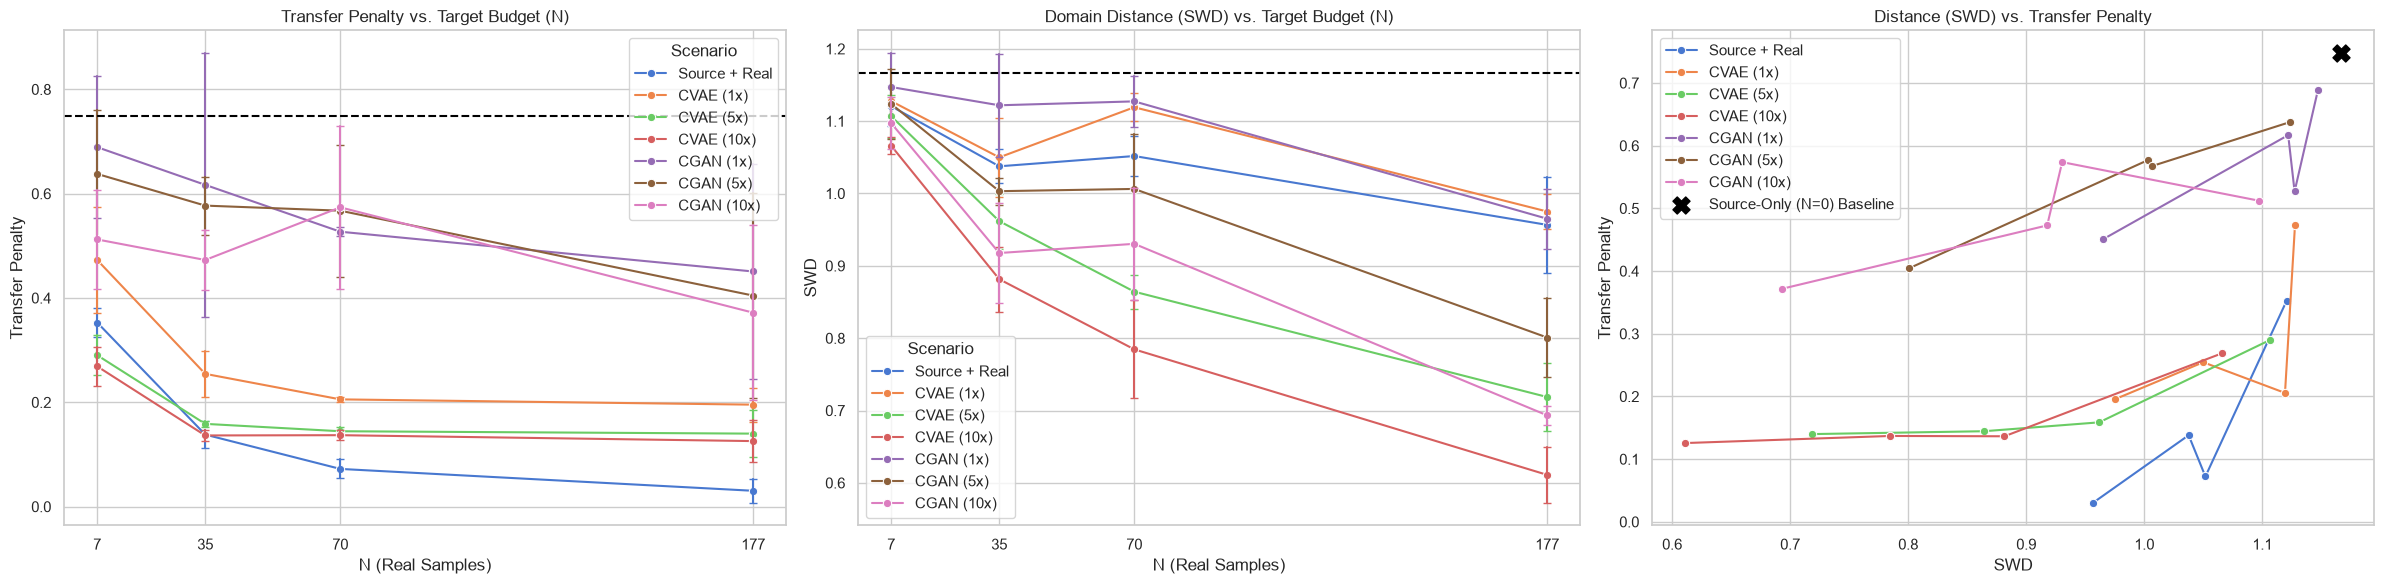

In [84]:
results_df = pd.DataFrame(results)
print("\n=== SWEEP RESULTS ===")
print(results_df.drop(columns=['Run']).groupby(['Scenario', 'Budget %']).mean().reset_index().to_string())

# Save to CSV
results_df.to_csv('stage3_budget_results.csv', index=False)
print("\nResults saved to stage3_budget_results.csv")

# Create a fixed hue order to guarantee colors match perfectly across all 3 plots!
hue_order = [s for s in results_df['Scenario'].unique() if s != 'Source-Only']
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
# Plot 1: Transfer Penalty vs N
sns.lineplot(data=results_df[results_df['Scenario'] != 'Source-Only'], 
             x='N (Real Samples)', y='Transfer Penalty', hue='Scenario', marker='o', 
             errorbar='sd', err_style='bars', err_kws={'capsize': 3}, hue_order=hue_order, ax=axes[0])
axes[0].axhline(results_df[results_df['Scenario'] == 'Source-Only']['Transfer Penalty'].mean(), 
                color='black', linestyle='--', label='Source-Only (N=0) Baseline')
axes[0].set_title('Transfer Penalty vs. Target Budget (N)')
axes[0].set_xticks([int(len(tgt_pool_anom) * p) for p in percentages])
# Plot 2: SWD vs N
sns.lineplot(data=results_df[results_df['Scenario'] != 'Source-Only'], 
             x='N (Real Samples)', y='SWD', hue='Scenario', marker='o', 
             errorbar='sd', err_style='bars', err_kws={'capsize': 3}, hue_order=hue_order, ax=axes[1])
axes[1].axhline(results_df[results_df['Scenario'] == 'Source-Only']['SWD'].mean(), 
                color='black', linestyle='--', label='Source-Only (N=0) Baseline')
axes[1].set_title('Domain Distance (SWD) vs. Target Budget (N)')
axes[1].set_xticks([int(len(tgt_pool_anom) * p) for p in percentages])
# Plot 3: Distance vs Penalty
agg_df = results_df.groupby(['Scenario', 'Budget %', 'N (Real Samples)']).mean().reset_index()
# By REMOVING "sort=False" from here, Seaborn automatically connects the points 
# from lowest SWD to highest SWD along the X-axis, eliminating the "budget" zig-zags!
sns.lineplot(data=agg_df[agg_df['Scenario'] != 'Source-Only'], 
             x='SWD', y='Transfer Penalty', hue='Scenario', marker='o', hue_order=hue_order, ax=axes[2])
baseline = agg_df[agg_df['Scenario'] == 'Source-Only'].iloc[0]
axes[2].scatter(baseline['SWD'], baseline['Transfer Penalty'], color='black', s=150, marker='X', label='Source-Only (N=0) Baseline', zorder=5)
handles, labels = axes[2].get_legend_handles_labels()
axes[2].legend(handles, labels)
axes[2].set_title('Distance (SWD) vs. Transfer Penalty')
plt.tight_layout()
plt.savefig('stage3_budget_plot.png')
plt.show()

## 7. Results

Because we ran the sweep across multiple independent seeds, our plots now include **shaded error bands representing the standard deviation**. Based on the 6 scenarios evaluated across the budget sweep, we can draw three major conclusions from the plots above:

1. **Transfer Penalty vs. Target Budget (N):** As expected, incorporating direct real target data (`Source + Real`) provides the best reduction in penalty. However, **`CVAE (10x)` follows very closely**, proving that the CVAE can effectively amplify the information of a tiny target budget to nearly rival the performance of using raw real data. The error bands confirm the CVAE is highly stable across random initializations. In almost all cases, the synthetic generators successfully reduce the penalty far below the `Source-Only` baseline.

2. **Domain Distance (SWD) vs. Target Budget (N):** The geometric distance to the target domain consistently decreases as budget $N$ increases. Notably, the `CVAE (10x)` reduces the domain distance *much more aggressively* than `Source + Real`. This indicates that large-scale synthetic generation actively reshapes the overall mathematical distribution closer to the target domain, whereas simply appending a few real points has a smaller mathematical impact on the global distribution.

3. **Distance (SWD) vs. Transfer Penalty:** The trajectory plot reveals a clear, overarching correlation: in general, as the mathematical distance (SWD) increases, so does the Transfer Penalty. While the relationship is not perfectly monotonic the macro trend across all scenarios strongly validates our Stage 2 hypothesis: bridging the mathematical domain distance successfully closes the Transfer Learning gap.
